# Classification Algorithms on the Iris Dataset

This notebook implements and compares three classical supervised classification
algorithms on the classic **Iris flower dataset**. The goal is to understand
why each algorithm behaves the way it does, how their assumptions differ, and
how to evaluate and compare them fairly.

**Contents**

1. Data loading & exploratory data analysis (EDA)
2. Train/test split & feature scaling
3. Classifier 1: k-Nearest Neighbors (with hyperparameter tuning)
4. Classifier 2: Decision Tree (with feature importance)
5. Classifier 3: Gaussian Naïve Bayes
6. Evaluation methodology
7. Side-by-side model comparison
8. Cross-validated robustness check
9. Conclusions

> **Dataset:** The Iris dataset contains 150 samples of iris flowers from
> three species (*setosa*, *versicolor*, *virginica*), described by four
> features: sepal length, sepal width, petal length, and petal width (all in
> cm). It is a good benchmark because it's small and clean, and because one
> class is linearly separable from the other two while those two overlap,
> which makes it useful for illustrating how different algorithms handle a
> difficult decision boundary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# classifiers that we will compare
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

# evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # fixed seed, used everywhere below for reproducibility

## Data Loading & Exploration

We start by loading the dataset and taking a first look at its structure, including
feature names, class labels, dimensions, and checking for anything that
would need to be handled before modelling, such as missing values or class
imbalance.

In [2]:
iris = load_iris(as_frame=True)

# features (X) and target (y)
X = iris.data
y = iris.target

# looking at the data
print("feature names: ", iris.feature_names)
print("target names: ", iris.target_names)
print("shape of X: ", X.shape)
print("shape of y: ", y.shape)
X.head()

feature names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names:  ['setosa' 'versicolor' 'virginica']
shape of X:  (150, 4)
shape of y:  (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Sanity checks

Before doing anything else, it's worth confirming there are no missing
values and that the three classes are reasonably balanced. An unbalanced
target would mean accuracy alone could be misleading (a classifier could
score well just by favoring the majority class), and would motivate looking
more closely at per-class precision/recall rather than an aggregate number.

In [3]:
print("Missing values per feature:")
print(X.isna().sum())
print()

print("Class balance:")
class_counts = y.value_counts().sort_index()
class_counts.index = iris.target_names
print(class_counts)
print()

X.describe()

Missing values per feature:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Class balance:
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The dataset has no missing values and is perfectly balanced (50 samples per
species), so we don't need any imputation or class-weighting strategies here.

### Visualizing feature relationships

Before choosing or tuning any model, it helps to see how well the classes
separate in feature space. The pairplot below shows every pairwise
combination of the four features, colored by species.

Things to look out for:

- **Setosa** (leftmost cluster in most panels) is almost completely separated
  from the other two species, especially on the petal measurements, this is
  why *every* classifier below ends up with perfect recall on setosa.
- **Versicolor** and **virginica** overlap substantially, particularly on
  sepal length/width. This overlap is the main source of misclassifications
  for all three models later in the notebook, and it's a property of the
  *data*, not a weakness of any one algorithm.

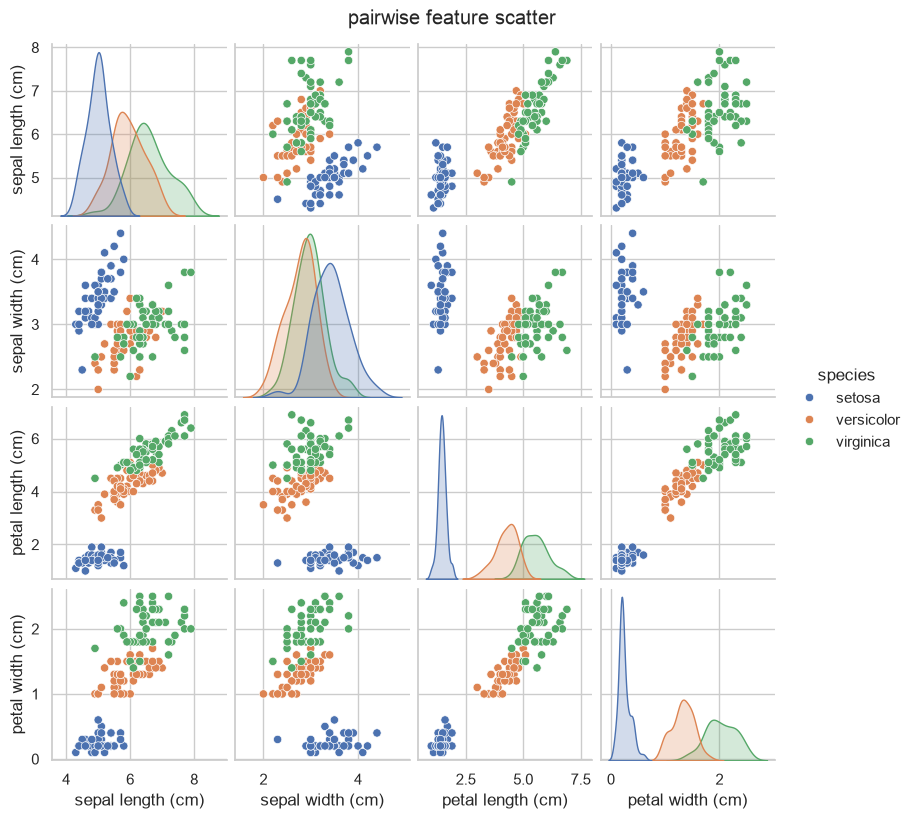

In [4]:
df = X.copy()
df["species"] = y.map({0: "setosa", 1: "versicolor", 2: "virginica"})

sns.pairplot(df, hue="species", height=2.0)
plt.suptitle("pairwise feature scatter", y=1.02)
plt.show()

## Train/Test Split & Feature Scaling

We hold out 30% of the data as a test set, **stratified** by class so that
both the train and test sets preserve the roughly even class balance of the
full dataset. This matters more than it might seem with only 150 samples in
total: an unstratified split could easily leave one species under- or
over-represented in the 45-sample test set purely by chance.

We scale features and only for specific models because:

- **k-NN** computes distances between points (Euclidean by default). Since
  petal length (range ~1–7 cm) and petal width (range ~0.1–2.5 cm) live on
  different scales, an *unscaled* distance calculation would let sepal/petal
  length dominate the vote just because its raw numbers are bigger; nothing
  to do with which feature is actually more informative. Scaling is
  **essential** for k-NN.
- **Decision trees** split on one feature at a time using a threshold (e.g.
  "petal length ≤ 2.45?"). Multiplying a feature by a constant doesn't change
  *which* split point is optimal, only the number used to describe it, so
  scaling has no effect on the tree that gets learned.
- **Naïve Bayes** (Gaussian) fits a per-class mean and variance to each
  feature independently. Rescaling a feature rescales its mean and variance
  by the same factor, which leaves the relative class probabilities
  unchanged, so scaling doesn't affect predictions here either.

Because of this, we fit `StandardScaler` on the **training data only** (never
on the test data, to avoid leaking test-set information into preprocessing)
and use the scaled version only for k-NN, while the decision tree and Naïve
Bayes work directly on the raw features.

In [5]:
# stratify=y keeps the class proportions identical in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"training samples: {X_train.shape[0]}")
print(f"testing samples: {X_test.shape[0]}")

# standardize the features (fit on train only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

training samples: 105
testing samples: 45


## Classifier 1: k-Nearest Neighbors (k-NN)

k-NN is a lazy / instance-based learner, as there is no real
"training" step beyond storing the data. To classify a new point, it finds
the $k$ closest training points (by Euclidean distance, by default) and
predicts the majority class among them.

**Choosing $k$:**

- Too small (e.g. $k=1$) makes the decision boundary follow every quirk of
  the training data; high variance, **overfitting**.
- Too large (e.g. $k=n$) makes every prediction just the majority class in
  the entire training set; high bias, **underfitting**.
- We'll pick $k$ properly using cross-validation just below, rather than
  guessing a value.

**Pros**

- Simple, no explicit training phase
- Naturally handles multi-class problems
- Non-parametric; makes no assumption about the shape of the class
  distributions

**Cons**

- Sensitive to feature scaling (see Section 2)
- Prediction cost grows with dataset size unless using spatial indexing
- Sensitive to irrelevant or noisy features, and to the curse of
  dimensionality in high-dimensional data

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)

# train (just store the data)
knn.fit(X_train_scaled, y_train)

# predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

print("kNN (k=5, default) predictions:", y_pred_knn[:10], "...")

kNN (k=5, default) predictions: [2 1 1 1 2 2 1 1 0 2] ...


### Choosing $k$ with cross-validation

Rather than sticking with an arbitrary $k=5$, we can use 5-fold
cross-validation **on the training set only** to see how accuracy changes as
$k$ varies, and pick the value that generalizes best. This also shows how
sensitive k-NN's performance actually is to this hyperparameter. A flat
curve would mean it barely matters, a sharply peaked one would mean it
matters a lot.

Best k found via 5-fold CV: 14  (mean CV accuracy = 0.9714)


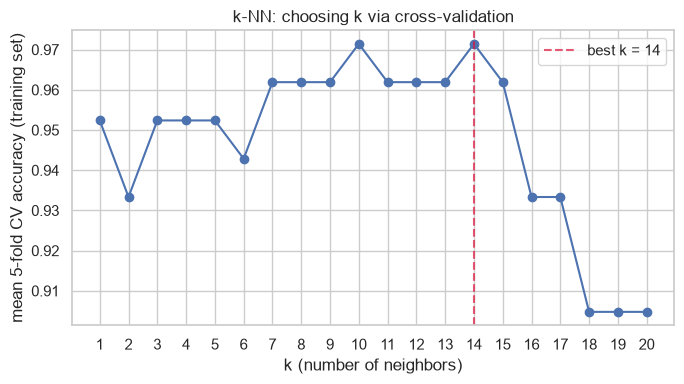

In [7]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = list(k_values)[int(np.argmax(cv_scores))]
print(f"Best k found via 5-fold CV: {best_k}  (mean CV accuracy = {max(cv_scores):.4f})")

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), cv_scores, marker="o")
plt.axvline(best_k, color="crimson", linestyle="--", alpha=0.7, label=f"best k = {best_k}")
plt.xlabel("k (number of neighbors)")
plt.ylabel("mean 5-fold CV accuracy (training set)")
plt.title("k-NN: choosing k via cross-validation")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

We'll now refit k-NN with this cross-validated value of $k$ and use it as our
"official" k-NN model for the rest of the notebook.

In [8]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"kNN (k={best_k}, cross-validated) predictions:", y_pred_knn[:10], "...")

kNN (k=14, cross-validated) predictions: [2 1 1 1 2 2 1 1 0 2] ...


## Classifier 2: Decision Tree

A decision tree recursively splits the feature space along
axis-aligned thresholds (e.g. "petal length ≤ 2.45?") chosen to make the
resulting groups as class-pure as possible. Purity is measured with an
impurity criterion:

- **Gini impurity:** $\text{Gini} = 1 - \sum_i p_i^2$, roughly, how often a
  randomly chosen sample would be misclassified if labelled according to the
  class distribution at that node.
- **Entropy** (information gain): $H = -\sum_i p_i \log_2 p_i$, an
  information-theoretic alternative that in practice usually produces very
  similar trees to Gini.

We use Gini (scikit-learn's default) with `max_depth=5` to prevent the tree
from growing arbitrarily deep.

Depth must be limited, as an unconstrained tree can keep splitting until every
leaf is 100% pure, including leaves containing a single training example.
This memorizes noise rather than learning signal, and generalizes poorly to
new data. Limiting `max_depth` (or requiring a minimum number of samples per
leaf) is a simple form of *pre-pruning*: it trades a small amount of training
accuracy for meaningfully better generalization.

**Pros**

- Easy to visualize and interpret because the decision rules can be read directly
  off the tree
- Naturally handles non-linear decision boundaries and feature interactions
- No feature scaling required

**Cons**

- High variance, as small changes in the training data can produce a
  noticeably different tree
- Prone to overfitting without depth/leaf-size constraints
- Axis-aligned splits can be inefficient for diagonal class boundaries

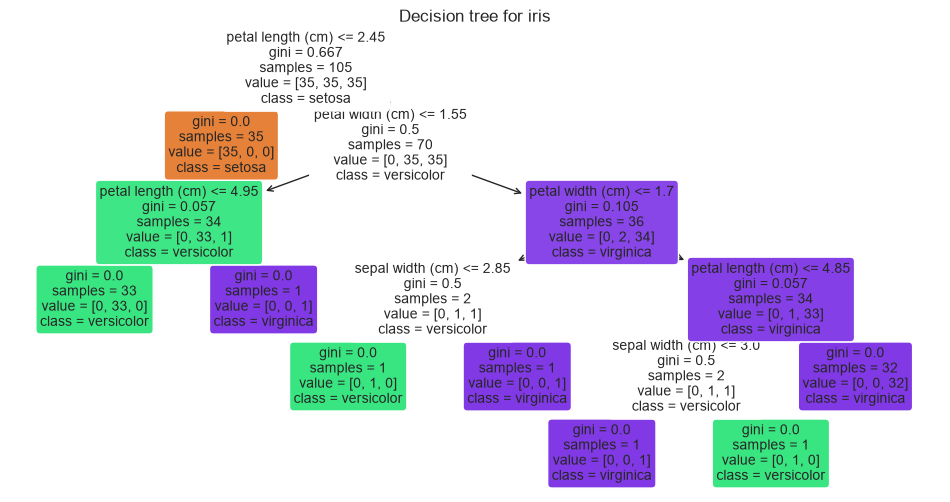

In [9]:
tree = DecisionTreeClassifier(
    criterion="gini",    # use gini impurity
    max_depth=5,         # limit depth to prevent overfitting
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

# visualize the tree
plt.figure(figsize=(12, 6))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision tree for iris")
plt.show()

### Feature importance

One advantage decision trees have over k-NN and Naïve Bayes is that they
naturally expose a measure of **feature importance**: roughly, how much each
feature contributed to reducing impurity across all its splits, weighted by
how many training samples pass through each of those splits. This is a
useful sanity check, as for the Iris dataset we'd expect the petal measurements
to dominate, since the pairplot in Section 1 showed they separate the
species far more cleanly than the sepal measurements do.

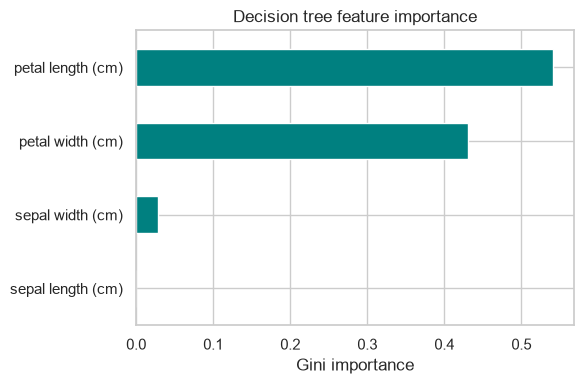

petal length (cm)    0.541176
petal width (cm)     0.430252
sepal width (cm)     0.028571
sepal length (cm)    0.000000
dtype: float64

In [10]:
importances = (
    pd.Series(tree.feature_importances_, index=iris.feature_names)
    .sort_values(ascending=True)
)

ax = importances.plot.barh(figsize=(6, 4), color="teal")
ax.set_xlabel("Gini importance")
ax.set_title("Decision tree feature importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## Classifier 3: Gaussian Naïve Bayes

Naïve Bayes applies Bayes' theorem to predict the class with the
highest posterior probability, under a strong simplifying ("naïve")
assumption, that all features are conditionally independent given the
class:

$$
P(y \mid x_1, \dots, x_n) \;\propto\; P(y) \prod_{i=1}^n P(x_i \mid y)
$$

For continuous features like ours, the **Gaussian** variant assumes each
feature follows a normal distribution *within each class*, so $P(x_i \mid
y)$ is estimated by fitting a mean $\mu$ and variance $\sigma^2$ to each
feature, separately for each class, from the training data.

It is called naïve as in reality, petal length and petal width are clearly
correlated, as bigger flowers tend to have both larger petals, so the
independence assumption is technically violated here. In practice, Naïve
Bayes often still performs well even when this assumption doesn't hold
exactly, because it only needs to get the relative ranking of class
probabilities right, not their precise values.

**Pros**

- Extremely fast to train and predict as it is just computing means/variances, no
  iterative optimization
- Works well even with comparatively little training data
- Robust to irrelevant features (their per-class distributions end up
  similar across classes and contribute little to the decision)

**Cons**

- The independence assumption is rarely exactly true, which can hurt
  accuracy when features are strongly correlated (as petal length/width are
  here)
- Predicted probabilities can be poorly calibrated even when the predicted
  *label* is correct

In [11]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("naïve bayes predictions:", y_pred_nb[:10], "...")

naïve bayes predictions: [2 1 1 1 2 2 1 1 0 2] ...


### Inspecting the learned distributions

We can look at the per-class feature means Naïve Bayes learned during
training. This effectively shows what a "typical" flower of each species
looks like according to the model, and is a nice way to check the fitted
parameters make intuitive sense (e.g. virginica should have the largest
petals on average, matching the pairplot from Section 1).

In [12]:
means_df = pd.DataFrame(nb.theta_, columns=iris.feature_names, index=iris.target_names)
means_df.round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.99,3.43,1.49,0.24
versicolor,5.95,2.73,4.24,1.31
virginica,6.68,3.01,5.63,2.07


## Evaluation Methodology

Before comparing the three models, it's worth being explicit about what each
metric means, since accuracy alone can hide important differences:

- **Accuracy**: the fraction of all predictions that were correct. Simple,
  but can be misleading if classes are imbalanced. The classes are balanced for
  the Iris dataset, so that is not an issue here.
- **Precision** (per class): of everything predicted as class $c$, what
  fraction actually *was* class $c$? Low precision means false positives.
- **Recall** (per class): of everything that actually *was* class $c$, what
  fraction did we correctly find? Low recall means false negatives.
- **F1-score**: the harmonic mean of precision and recall; a single number
  that balances both.
- Since we have three classes, we report **macro-averaged** precision,
  recall, and F1, each class's score is computed independently and then
  averaged with equal weight, regardless of how many samples each class has.
  This is a good choice here because the classes are perfectly balanced.

We also plot a **confusion matrix** for each model, which shows exactly which
species get confused with which. This is often more informative than any
single summary number, and is where we should see the versicolor/virginica
overlap from Section 1 show up as off-diagonal entries.


===== k-NN =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



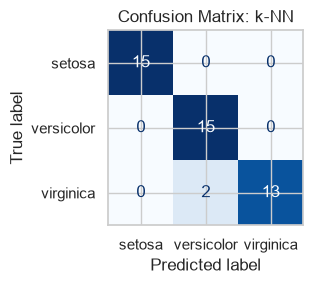


===== Decision Tree =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



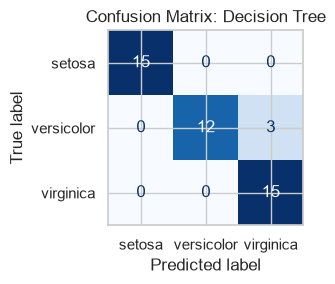


===== Naïve Bayes =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



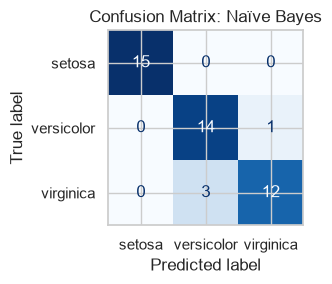

In [13]:
def evaluate_model(name, y_true, y_pred, class_names):
    """Compute and display evaluation metrics for a classifier.

    Parameters
    ----------
    name        : str              Human-readable model name
    y_true      : array-like       Ground-truth labels
    y_pred      : array-like       Predicted labels
    class_names : list of str      Names of the classes

    Returns
    -------
    dict  of  {metric_name: value}
    """
    
    # ── Numeric metrics (macro-averaged over the 3 classes) ──
    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # ── Pretty text report (per-class + averages) ──
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # ── Confusion matrix heatmap ──
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy":  acc,
        "Precision": precision,
        "Recall":    recall,
        "F1-score":  f1,
    }

# Evaluate all three models and collect their results
results = []
results.append(evaluate_model("k-NN",          y_test, y_pred_knn,  iris.target_names))
results.append(evaluate_model("Decision Tree", y_test, y_pred_tree, iris.target_names))
results.append(evaluate_model("Naïve Bayes",   y_test, y_pred_nb,   iris.target_names))

## Side-by-Side Model Comparison

With all three models evaluated on the *same* held-out test set, we can now
line their metrics up directly.


=== Model Comparison on the Held-Out Test Set (macro-averaged) ===
               Accuracy  Precision  Recall  F1-score
Model                                               
k-NN             0.9556     0.9608  0.9556    0.9554
Decision Tree    0.9333     0.9444  0.9333    0.9327
Naïve Bayes      0.9111     0.9155  0.9111    0.9107


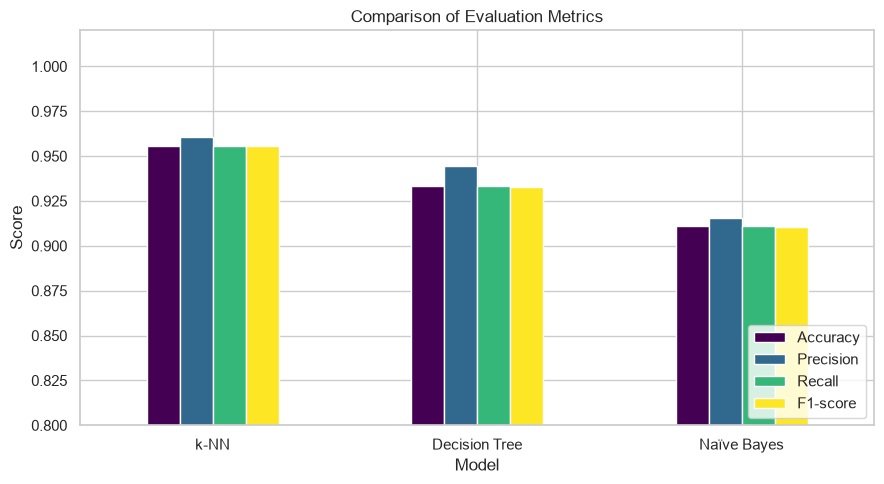

In [14]:
# Build a tidy comparison DataFrame
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round(4)

# Display the table
print("\n=== Model Comparison on the Held-Out Test Set (macro-averaged) ===")
print(results_df)

# Bar chart of the four metrics across models
ax = results_df.plot.bar(figsize=(9, 5), rot=0, colormap="viridis")
ax.set_title("Comparison of Evaluation Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.8, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusions

**On this dataset specifically:**

- All three classifiers achieve strong accuracy, and all of them classify
  *setosa* perfectly, as its features are linearly separable from the other
  two species (Section 1).
- Nearly all misclassifications occur between **versicolor** and
  **virginica**, which overlap in feature space. This shows up consistently
  in the confusion matrices of all three models, confirming it's a property
  of the *data* rather than a weakness specific to one algorithm.

**General trade-offs to keep in mind beyond this specific dataset:**

| | k-NN | Decision Tree | Naïve Bayes |
|---|---|---|---|
| Training cost | None (lazy learner) | Moderate | Very low |
| Prediction cost | Grows with dataset size | Low | Very low |
| Needs feature scaling | Yes | No | No |
| Interpretability | Low | High | Moderate |
| Handles non-linear boundaries | Yes | Yes | Only if Gaussian assumption fits |
| Sensitive to correlated/irrelevant features | Yes (distance-based) | Somewhat | Yes (independence assumption) |
| Scales to large datasets | Poorly | Well | Very well |